In [1]:
from ISLP import load_data
import pandas as pd
import numpy as np
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS, summarize

**15.** \
This problem involves the Boston data set, which we saw in the lab for this chapter.\
We will now try to predict per capita crime rate using the other variables in this data set.\
In other words, per capita crime rate is the response, and the other variables are the predictors

In [2]:
boston = load_data('Boston')
row_count = boston.shape[0]

In [43]:
y = boston['crim']
y.describe()
# measure the number of crimes per 100,000 residents

count    506.000000
mean       3.613524
std        8.601545
min        0.006320
25%        0.082045
50%        0.256510
75%        3.677083
max       88.976200
Name: crim, dtype: float64

**(a)** For each predictor, fit a simple linear regression model to predict the response. \
Describe your results.\
In which of the models is there a statistically significant association between the predictor and the response? \
Create some plots to back up your assertions.

In [8]:
predictors = boston.columns.drop('crim')

### Relationship btw proportion of low density zoning and per capita crime rate

In [5]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    '% of low-density zoning': boston['zn']})

<Axes: xlabel='zn', ylabel='crim'>

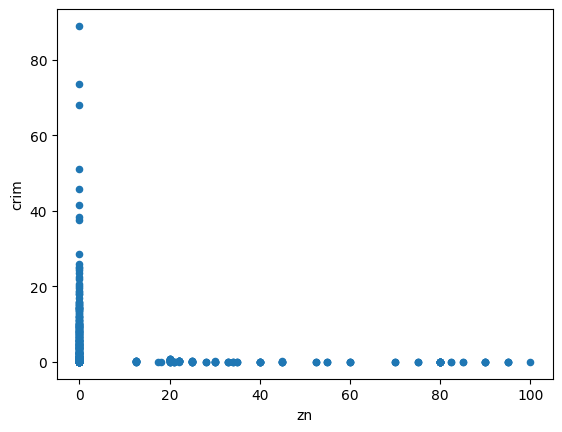

In [6]:
boston.plot.scatter('zn', 'crim')

In [7]:
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,4.4537,0.417,10.675,0.0
% of low-density zoning,-0.0739,0.016,-4.594,0.0


## Relationship between % of non-retail bussiness & per-capita crime

<Axes: xlabel='indus', ylabel='crim'>

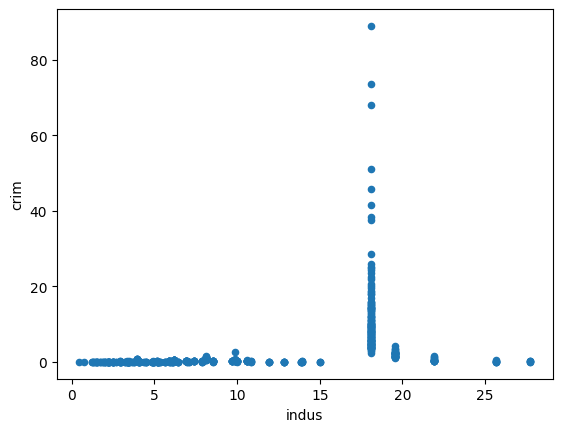

In [9]:
boston.plot.scatter('indus', 'crim')

In [10]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    '% of non-retail business': boston['indus']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-2.0637,0.667,-3.093,0.002
% of non-retail business,0.5098,0.051,9.991,0.000


### Charles River bound? 

crim    Axes(0.125,0.11;0.775x0.77)
dtype: object

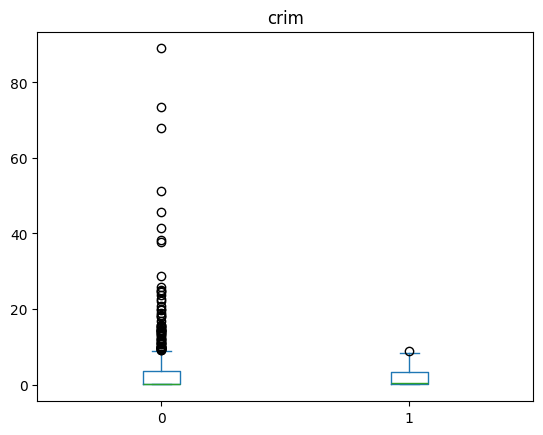

In [18]:
river_bound = pd.DataFrame(boston[['chas', 'crim']])
river_bound.plot.box(column="crim", by="chas")

In [19]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    'is location close to charles river': boston['chas']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,3.7444,0.396,9.453,0.000
is location close to charles river,-1.8928,1.506,-1.257,0.209


### nitrogen oxides concentration & crime rate

<Axes: xlabel='nox', ylabel='crim'>

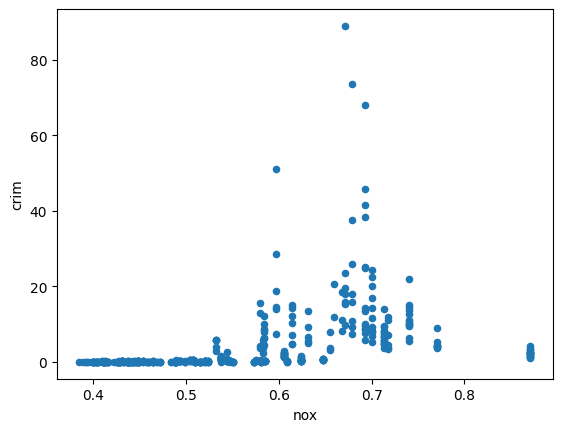

In [20]:
boston.plot.scatter('nox', 'crim')

In [21]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    'nitrogen oxides concentration': boston['nox']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-13.7199,1.699,-8.073,0.0
nitrogen oxides concentration,31.2485,2.999,10.419,0.0


### average number of rooms per dwelling & crime rate

<Axes: xlabel='rm', ylabel='crim'>

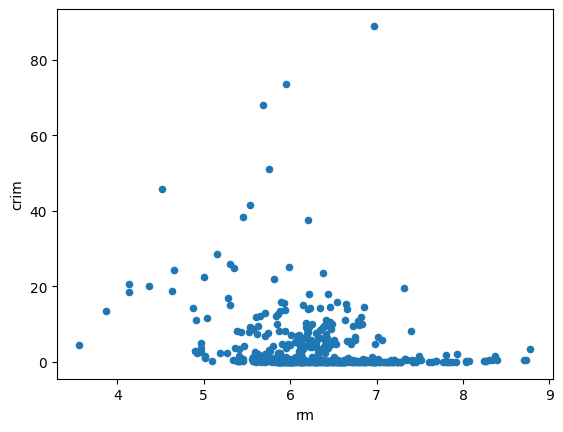

In [22]:
boston.plot.scatter('rm', 'crim')

In [23]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    'average number of rooms per dwelling': boston['rm']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,20.4818,3.364,6.088,0.0
average number of rooms per dwelling,-2.6841,0.532,-5.045,0.0


### % of old houses & crime rate 

<Axes: xlabel='age', ylabel='crim'>

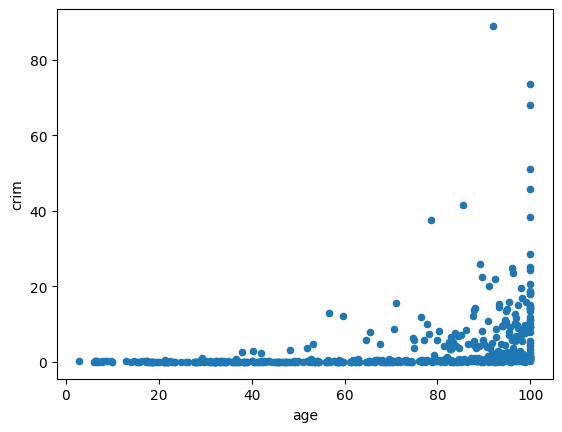

In [25]:
boston.plot.scatter('age', 'crim')

In [26]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    'proportion of owner-occupied units built prior to 1940': boston['age']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-3.7779,0.944,-4.002,0.0
proportion of owner-occupied units built prior to 1940,0.1078,0.013,8.463,0.0


### Distance to employment center & crime rate

<Axes: xlabel='dis', ylabel='crim'>

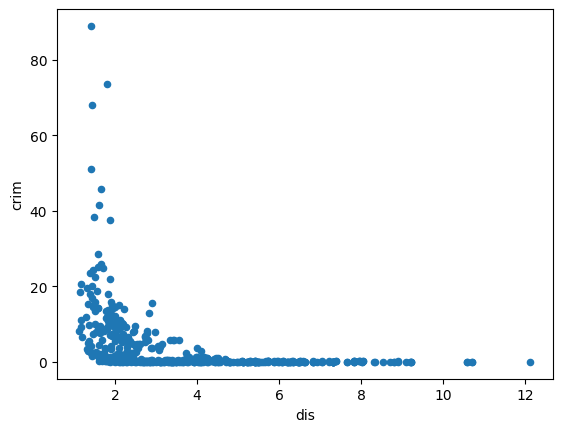

In [27]:
boston.plot.scatter('dis', 'crim')

In [28]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    'weighted mean of distances to five Boston employment centres': boston['dis']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,9.4993,0.730,13.006,0.0
weighted mean of distances to five Boston employment centres,-1.5509,0.168,-9.213,0.0


### accessibility to radial highways & crime rate

crim    Axes(0.125,0.11;0.775x0.77)
dtype: object

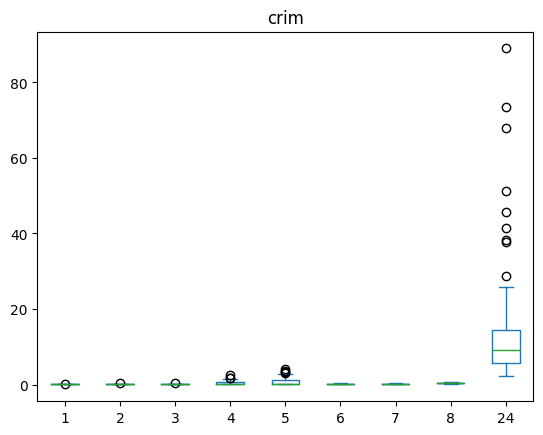

In [30]:
highway_accessibility_index = pd.DataFrame(boston[['rad', 'crim']])
highway_accessibility_index.plot.box(column="crim", by="rad")

In [31]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    'redial highway accessibility index': boston['rad']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-2.2872,0.443,-5.157,0.0
redial highway accessibility index,0.6179,0.034,17.998,0.0


### Property tax rate & crime rate

<Axes: xlabel='tax', ylabel='crim'>

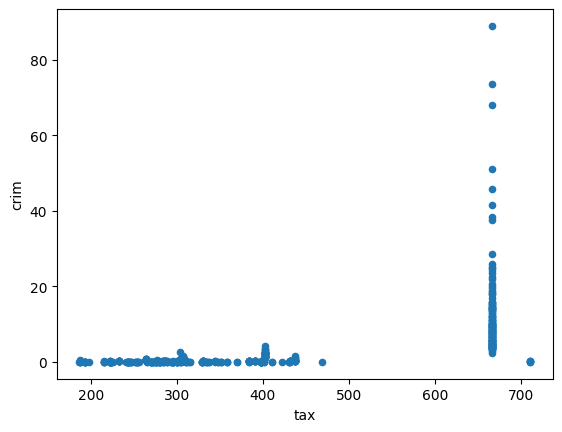

In [32]:
boston.plot.scatter('tax', 'crim')

In [33]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    'full-value property-tax rate per $10,000': boston['tax']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-8.5284,0.816,-10.454,0.0
"full-value property-tax rate per $10,000",0.0297,0.002,16.099,0.0


### pupil-teacher ratio & crime rate

<Axes: xlabel='ptratio', ylabel='crim'>

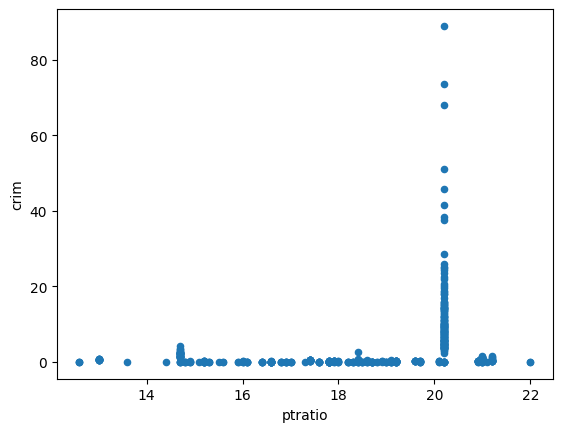

In [34]:
boston.plot.scatter('ptratio', 'crim')

In [35]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    ' pupil-teacher ratio': boston['ptratio']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-17.6469,3.147,-5.607,0.0
pupil-teacher ratio,1.1520,0.169,6.801,0.0


### Disadvantaged population & crime rate 

<Axes: xlabel='lstat', ylabel='crim'>

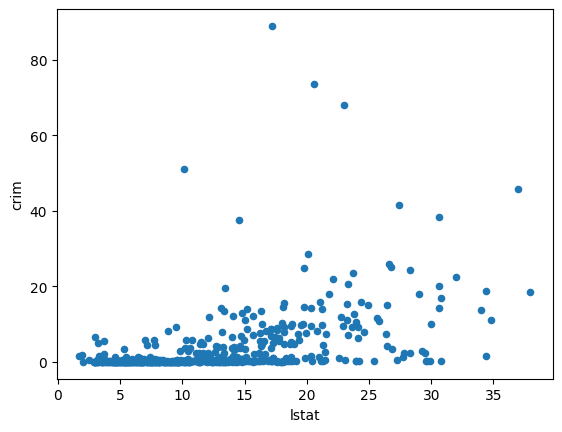

In [36]:
boston.plot.scatter('lstat', 'crim')

In [37]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    '% of distadvantaged population': boston['lstat']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-3.3305,0.694,-4.801,0.0
% of distadvantaged population,0.5488,0.048,11.491,0.0


### median home value & crime rate

<Axes: xlabel='medv', ylabel='crim'>

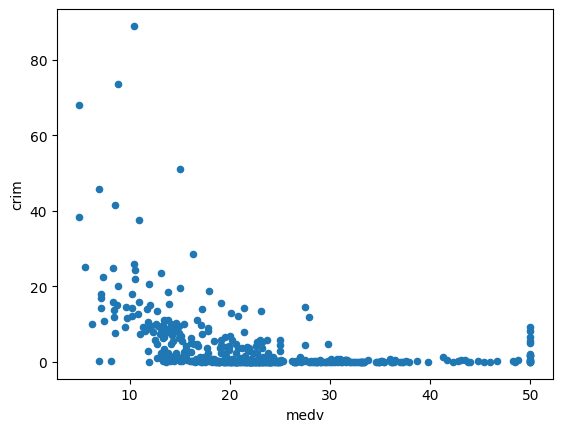

In [38]:
boston.plot.scatter('medv', 'crim')

In [40]:
x = pd.DataFrame(
    {'intercept': np.ones(row_count),
    'median home value': boston['medv']})
model = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,11.7965,0.934,12.628,0.0
median home value,-0.3632,0.038,-9.460,0.0


**(b)** Fit a multiple regression model to predict the response using all of the predictors.\
Describe your results.\
For which predictors can we reject the null hypothesis H0 : βj = 0?

In [50]:
x = MS(predictors).fit_transform(boston)
model = sm.OLS(y, x)
result = model.fit()
summarize(result)

,coef,std err,t,P>|t|
intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


In [55]:
insignificant_factors = ['indus', 'chas', 'age', 'tax', 'rm', 'zn']
new_predictors = predictors.drop(insignificant_factors)
new_predictors

Index(['nox', 'dis', 'rad', 'ptratio', 'lstat', 'medv'], dtype='object')

In [56]:
x = MS(new_predictors).fit_transform(boston)
model = sm.OLS(y, x)
result = model.fit()
summarize(result)

,coef,std err,t,P>|t|
intercept,18.6119,6.038,3.082,0.002
nox,-12.9753,4.797,-2.705,0.007
dis,-0.6196,0.230,-2.697,0.007
rad,0.5851,0.047,12.335,0.000
ptratio,-0.4742,0.177,-2.686,0.007
lstat,0.1247,0.070,1.789,0.074
medv,-0.1714,0.053,-3.208,0.001
